# Requirement 2 — Budgeted Combinatorial-UCB



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools


In [ ]:
class MultiCampaignStochasticEnvironment:
    def __init__(self, market_price_vectors, probabilities, seed=None):
        self.market_price_vectors = np.array(market_price_vectors)
        self.probabilities = np.array(probabilities)
        assert np.isclose(self.probabilities.sum(), 1.0)
        self.S, self.N = self.market_price_vectors.shape
        self.rng = np.random.default_rng(seed)

    def round(self):
        scenario = self.rng.choice(self.S, p=self.probabilities)
        return self.market_price_vectors[scenario]


def compute_multi_campaign_outcome(bids, market_prices, valuations):
    bids = np.array(bids)
    market_prices = np.array(market_prices)
    valuations = np.array(valuations)
    wins = bids >= market_prices
    rewards_per_campaign = np.where(wins, valuations - bids, 0.0)
    costs_per_campaign = np.where(wins, bids, 0.0)
    return rewards_per_campaign.sum(), costs_per_campaign.sum(), wins, rewards_per_campaign, costs_per_campaign


def compute_true_expected_matrices(bids_set, valuations, market_price_vectors, probabilities):
    bids_set = np.array(bids_set)
    valuations = np.array(valuations)
    market_price_vectors = np.array(market_price_vectors)
    probabilities = np.array(probabilities)
    S, N = market_price_vectors.shape
    K = len(bids_set)
    expected_rewards = np.zeros((N, K))
    expected_costs = np.zeros((N, K))
    for i in range(N):
        for k, bid in enumerate(bids_set):
            wins = market_price_vectors[:, i] <= bid
            expected_rewards[i, k] = np.sum(probabilities * np.where(wins, valuations[i] - bid, 0.0))
            expected_costs[i, k] = np.sum(probabilities * np.where(wins, bid, 0.0))
    return expected_rewards, expected_costs


def is_action_feasible_with_conflicts(action, conflict_edges):
    if conflict_edges is None:
        return True
    for i, j in conflict_edges:
        if action[i] > 0 and action[j] > 0:
            return False
    return True


def enumerate_conflict_feasible_actions(bids_set, N, conflict_edges=None):
    actions = []
    action_indices = []
    for indices in itertools.product(range(len(bids_set)), repeat=N):
        action = np.array([bids_set[k] for k in indices])
        if is_action_feasible_with_conflicts(action, conflict_edges):
            actions.append(action)
            action_indices.append(indices)
    return np.array(actions), np.array(action_indices, dtype=int)


## Parameters


In [ ]:
T = 20_000
N = 4
valuations = np.array([1.0, 0.9, 0.8, 0.7])
bids_set = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
total_budget = 6000.0
rho = total_budget / T

market_price_vectors = np.array([
    [0.1, 0.2, 0.3, 0.2],
    [0.2, 0.3, 0.4, 0.3],
    [0.3, 0.4, 0.5, 0.4],
    [0.4, 0.5, 0.6, 0.5],
    [0.5, 0.6, 0.7, 0.6],
])
probabilities = np.array([0.20, 0.25, 0.25, 0.20, 0.10])
conflict_edges = [(0, 1), (2, 3)]

print("rho =", rho)
print("Total budget =", total_budget)


rho = 0.3
Total budget = 6000.0


In [ ]:
true_expected_rewards, true_expected_costs = compute_true_expected_matrices(
    bids_set, valuations, market_price_vectors, probabilities
)

actions, action_indices = enumerate_conflict_feasible_actions(bids_set, N, conflict_edges)
A = len(actions)

true_action_rewards = true_expected_rewards[np.arange(N)[:, None], action_indices.T].sum(axis=0)
true_action_costs = true_expected_costs[np.arange(N)[:, None], action_indices.T].sum(axis=0)
action_max_payments = actions.sum(axis=1)
zero_action_id = int(np.where(np.all(np.isclose(actions, 0.0), axis=1))[0][0])

print("Number of conflict-feasible combinatorial actions:", A)
print("Best single action with E[cost] <= rho:")
single_feasible = np.where(true_action_costs <= rho + 1e-12)[0]
best_single = single_feasible[np.argmax(true_action_rewards[single_feasible])]
print(" action =", actions[best_single], "E[r] =", round(true_action_rewards[best_single], 4), "E[c] =", round(true_action_costs[best_single], 4))
print("This explains why a fixed-single-action TP benchmark under-consumes the budget.")


Number of conflict-feasible combinatorial actions: 81
Best single action with E[cost] <= rho:
 action = [0.2 0.  0.4 0. ] E[r] = 0.54 E[c] = 0.27
This explains why a fixed-single-action TP benchmark under-consumes the budget.


## Fast LP oracle for the best budgeted distribution

In [ ]:
pair_i, pair_j = np.meshgrid(np.arange(A), np.arange(A), indexing="ij")
pair_i = pair_i.ravel()
pair_j = pair_j.ravel()


def best_budgeted_mixture(values, costs, budget, allowed=None):
    values = np.asarray(values, dtype=float)
    costs = np.asarray(costs, dtype=float)
    if allowed is None:
        allowed = np.ones(len(values), dtype=bool)

    # Single feasible actions.
    single_mask = allowed & (costs <= budget + 1e-12)
    best_value = -np.inf
    best_tuple = (zero_action_id, zero_action_id, 1.0)

    if np.any(single_mask):
        candidates = np.where(single_mask)[0]
        j = int(candidates[np.argmax(values[candidates])])
        best_value = float(values[j])
        best_tuple = (j, j, 1.0)

    # Two-action mixtures with one action below and one above the budget.
    ci = costs[pair_i]
    cj = costs[pair_j]
    pair_allowed = allowed[pair_i] & allowed[pair_j]
    pair_mask = pair_allowed & (ci <= budget + 1e-12) & (cj >= budget - 1e-12) & (np.abs(ci - cj) > 1e-12)

    if np.any(pair_mask):
        ii = pair_i[pair_mask]
        jj = pair_j[pair_mask]
        ci_m = costs[ii]
        cj_m = costs[jj]
        w_low = (cj_m - budget) / (cj_m - ci_m)  # probability of the low-cost action ii
        w_low = np.clip(w_low, 0.0, 1.0)
        mixture_values = w_low * values[ii] + (1.0 - w_low) * values[jj]
        m = int(np.argmax(mixture_values))
        if mixture_values[m] > best_value + 1e-12:
            best_value = float(mixture_values[m])
            best_tuple = (int(ii[m]), int(jj[m]), float(w_low[m]))

    return best_tuple, best_value


(best_i, best_j, best_w), clairvoyant_expected_reward = best_budgeted_mixture(
    true_action_rewards, true_action_costs, rho
)
clairvoyant_expected_cost = best_w * true_action_costs[best_i] + (1 - best_w) * true_action_costs[best_j]

print("Budgeted clairvoyant distribution:")
print(f" action 1: gamma={best_w:.4f}, action={actions[best_i]}, E[r]={true_action_rewards[best_i]:.4f}, E[c]={true_action_costs[best_i]:.4f}")
print(f" action 2: gamma={1-best_w:.4f}, action={actions[best_j]}, E[r]={true_action_rewards[best_j]:.4f}, E[c]={true_action_costs[best_j]:.4f}")
print("Clairvoyant E[r] per round:", round(clairvoyant_expected_reward, 4))
print("Clairvoyant E[c] per round:", round(clairvoyant_expected_cost, 4))
print("rho:", rho)


Budgeted clairvoyant distribution:
 action 1: gamma=0.3704, action=[0.2 0.  0.  0.2], E[r]=0.4600, E[c]=0.1300
 action 2: gamma=0.6296, action=[0.4 0.  0.  0.2], E[r]=0.6400, E[c]=0.4000
Clairvoyant E[r] per round: 0.5733
Clairvoyant E[c] per round: 0.3
rho: 0.3


## Budget-consuming Combinatorial-UCB learner


In [ ]:
class BudgetedDistributionCombinatorialUCB:
    def __init__(self, bids_set, valuations, actions, action_indices, true_action_costs, total_budget, T, alpha=0.05, seed=None):
        self.bids_set = np.array(bids_set)
        self.valuations = np.array(valuations)
        self.actions = np.array(actions)
        self.action_indices = np.array(action_indices, dtype=int)
        self.true_action_costs = np.array(true_action_costs)
        self.total_budget = total_budget
        self.remaining_budget = total_budget
        self.T = T
        self.alpha = alpha
        self.rng = np.random.default_rng(seed)
        self.N = len(valuations)
        self.K = len(bids_set)
        self.A = len(actions)
        self.t = 0

        self.n_pulls = np.zeros((self.N, self.K))
        self.reward_sum = np.zeros((self.N, self.K))
        self.cost_sum = np.zeros((self.N, self.K))
        self.avg_reward = np.zeros((self.N, self.K))
        self.avg_cost = np.zeros((self.N, self.K))

        self.containing = [[np.where(self.action_indices[:, i] == k)[0] for k in range(self.K)] for i in range(self.N)]

    def _base_reward_ucb(self):
        avg = np.divide(self.reward_sum, self.n_pulls, out=np.zeros_like(self.reward_sum), where=self.n_pulls > 0)
        bonus = np.zeros_like(avg)
        pulled = self.n_pulls > 0
        bonus[pulled] = np.sqrt(self.alpha * np.log(max(2, self.t)) / self.n_pulls[pulled])
        ucb = avg + bonus
        ucb[~pulled] = np.inf
        return ucb

    def _forced_exploration_action(self):
        for i in range(self.N):
            for k in range(self.K):
                if self.n_pulls[i, k] == 0:
                    for action_id in self.containing[i][k]:
                        if action_max_payments[action_id] <= self.remaining_budget + 1e-12:
                            return int(action_id)
        return None

    def select_distribution_and_action(self):
        self.t += 1
        if self.remaining_budget <= 1e-12:
            gamma = np.zeros(self.A)
            gamma[zero_action_id] = 1.0
            return zero_action_id, gamma

        forced = self._forced_exploration_action()
        if forced is not None:
            # Explore the forced action while keeping the selected distribution budget-feasible.
            # If the action is too costly in expectation, mix it with the zero action.
            gamma = np.zeros(self.A)
            c_forced = self.true_action_costs[forced]
            budget_now = min(self.total_budget / self.T, self.remaining_budget / max(1, self.T - self.t + 1))
            if c_forced <= budget_now + 1e-12:
                gamma[forced] = 1.0
            else:
                w_forced = budget_now / c_forced if c_forced > 1e-12 else 1.0
                w_forced = float(np.clip(w_forced, 0.0, 1.0))
                gamma[forced] = w_forced
                gamma[zero_action_id] = 1.0 - w_forced
            sampled_action = int(self.rng.choice(self.A, p=gamma / gamma.sum()))
            return sampled_action, gamma

        reward_ucb_matrix = self._base_reward_ucb()
        optimistic_action_values = reward_ucb_matrix[np.arange(self.N)[:, None], self.action_indices.T].sum(axis=0)

        # Hard realized safety: if all auctions were won, the payment would be sum of bids.
        allowed = action_max_payments <= self.remaining_budget + 1e-12

        # Fixed per-round budget used in the regret benchmark.
        # This keeps every selected distribution in the same feasible set as the clairvoyant.
        # If the remaining budget becomes smaller near the end, we automatically tighten it.
        rho_t = min(self.total_budget / self.T, self.remaining_budget / max(1, self.T - self.t + 1))

        (i, j, w), _ = best_budgeted_mixture(
            values=optimistic_action_values,
            costs=self.true_action_costs,
            budget=rho_t,
            allowed=allowed,
        )

        gamma = np.zeros(self.A)
        gamma[i] += w
        gamma[j] += 1.0 - w
        gamma = gamma / gamma.sum()
        sampled_action = int(self.rng.choice(self.A, p=gamma))
        return sampled_action, gamma

    def update(self, action_id, rewards_per_campaign, costs_per_campaign):
        self.remaining_budget = max(0.0, self.remaining_budget - float(np.sum(costs_per_campaign)))
        selected_indices = self.action_indices[action_id]
        for i, k in enumerate(selected_indices):
            self.n_pulls[i, k] += 1
            self.reward_sum[i, k] += rewards_per_campaign[i]
            self.cost_sum[i, k] += costs_per_campaign[i]
            self.avg_reward[i, k] = self.reward_sum[i, k] / self.n_pulls[i, k]
            self.avg_cost[i, k] = self.cost_sum[i, k] / self.n_pulls[i, k]


## Simulation

In [ ]:
def run_one_trial(seed=0, alpha=2.0):
    env = MultiCampaignStochasticEnvironment(
        market_price_vectors,
        probabilities,
        seed=seed
    )

    agent = BudgetedDistributionCombinatorialUCB(
        bids_set=bids_set,
        valuations=valuations,
        actions=actions,
        action_indices=action_indices,
        true_action_costs=true_action_costs,
        total_budget=total_budget,
        T=T,
        alpha=alpha,
        seed=10_000 + seed,
    )

    distribution_expected_rewards = np.zeros(T)
    distribution_expected_costs = np.zeros(T)
    realized_rewards = np.zeros(T)
    realized_costs = np.zeros(T)
    sampled_action_ids = np.zeros(T, dtype=int)

    for t in range(T):
        action_id, gamma = agent.select_distribution_and_action()

        selected_bids = actions[action_id]
        market_prices = env.round()

        total_reward, total_cost, wins, rewards_per_campaign, costs_per_campaign = (
            compute_multi_campaign_outcome(
                selected_bids,
                market_prices,
                valuations
            )
        )

        # Hard budget safety:
        # if the sampled realization would exceed the remaining budget,
        # play the zero action instead.
        if total_cost > agent.remaining_budget + 1e-12:
            action_id = zero_action_id
            selected_bids = actions[action_id]
            total_reward = 0.0
            total_cost = 0.0
            rewards_per_campaign = np.zeros(N)
            costs_per_campaign = np.zeros(N)

        agent.update(action_id, rewards_per_campaign, costs_per_campaign)

        sampled_action_ids[t] = action_id
        distribution_expected_rewards[t] = float(gamma @ true_action_rewards)
        distribution_expected_costs[t] = float(gamma @ true_action_costs)
        realized_rewards[t] = total_reward
        realized_costs[t] = total_cost

    pseudo_regret = np.cumsum(
        clairvoyant_expected_reward - distribution_expected_rewards
    )

    realized_regret = np.cumsum(
        clairvoyant_expected_reward - realized_rewards
    )

    return {
        "pseudo_regret": pseudo_regret,
        "realized_regret": realized_regret,
        "cum_cost": np.cumsum(realized_costs),
        "cum_reward": np.cumsum(realized_rewards),
        "distribution_expected_rewards": distribution_expected_rewards,
        "distribution_expected_costs": distribution_expected_costs,
        "sampled_action_ids": sampled_action_ids,
        "remaining_budget": agent.remaining_budget,
        "agent": agent,
    }


n_trials = 20
alpha = 2.0

outputs = [
    run_one_trial(seed=s, alpha=alpha)
    for s in range(n_trials)
]

pseudo_regret_trials = np.array([
    out["pseudo_regret"]
    for out in outputs
])

realized_regret_trials = np.array([
    out["realized_regret"]
    for out in outputs
])

cost_trials = np.array([
    out["cum_cost"]
    for out in outputs
])

reward_trials = np.array([
    out["cum_reward"]
    for out in outputs
])

distribution_expected_reward_trials = np.array([
    out["distribution_expected_rewards"]
    for out in outputs
])

distribution_expected_cost_trials = np.array([
    out["distribution_expected_costs"]
    for out in outputs
])

# Mean curves
avg_pseudo_regret = pseudo_regret_trials.mean(axis=0)
avg_realized_regret = realized_regret_trials.mean(axis=0)
avg_cost = cost_trials.mean(axis=0)
avg_reward = reward_trials.mean(axis=0)
avg_distribution_expected_cost = distribution_expected_cost_trials.mean(axis=0)

# Standard deviations across trials.
# ddof=1 gives the unbiased empirical standard deviation.
std_pseudo_regret = pseudo_regret_trials.std(axis=0, ddof=1)
std_realized_regret = realized_regret_trials.std(axis=0, ddof=1)
std_cost = cost_trials.std(axis=0, ddof=1)
std_reward = reward_trials.std(axis=0, ddof=1)

# 95% confidence intervals for the mean.
ci95_pseudo_regret = 1.96 * std_pseudo_regret / np.sqrt(n_trials)
ci95_realized_regret = 1.96 * std_realized_regret / np.sqrt(n_trials)
ci95_cost = 1.96 * std_cost / np.sqrt(n_trials)
ci95_reward = 1.96 * std_reward / np.sqrt(n_trials)

print("n_trials:", n_trials)
print("alpha:", alpha)
print("Average final pseudo-regret:", round(avg_pseudo_regret[-1], 3))
print("Average final pseudo-regret / T:", round(avg_pseudo_regret[-1] / T, 5))
print("Average final realized regret:", round(avg_realized_regret[-1], 3))
print("Average final realized cost:", round(avg_cost[-1], 3), "/", total_budget)
print("Remaining budget on average:", round(total_budget - avg_cost[-1], 3))
print("Average final realized reward:", round(avg_reward[-1], 3))
print(
    "Average expected cost per round selected by the learner:",
    round(avg_distribution_expected_cost.mean(), 5)
)
print("Budget per-round rho:", round(total_budget / T, 5))
print(
    "Any realized budget violation?",
    bool(np.any(cost_trials[:, -1] > total_budget + 1e-9))
)
print(
    "Pseudo-regret curves nondecreasing?",
    bool(np.all(np.diff(pseudo_regret_trials, axis=1) >= -1e-10))
)

n_trials: 20
alpha: 2.0
Average final pseudo-regret: 903.432
Average final pseudo-regret / T: 0.04517
Average final realized regret: 897.977
Average final realized cost: 5979.8 / 6000.0
Remaining budget on average: 20.2
Average final realized reward: 10568.69
Average expected cost per round selected by the learner: 0.29898
Budget per-round rho: 0.3
Any realized budget violation? False
Pseudo-regret curves nondecreasing? True


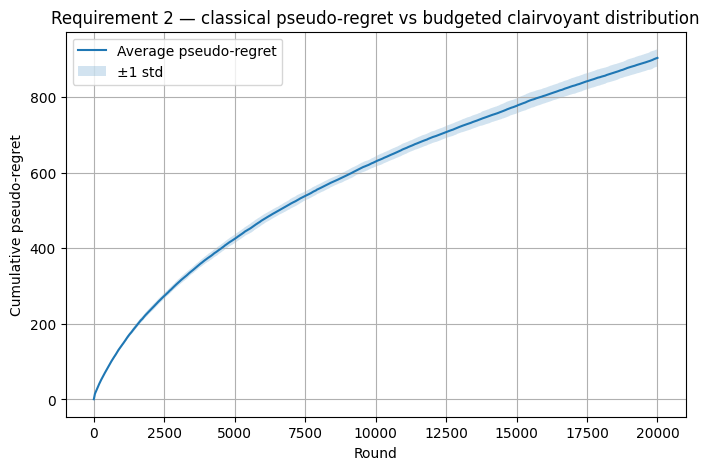

In [ ]:
x = np.arange(1, T + 1)
plt.figure(figsize=(8, 5))
plt.plot(x, avg_pseudo_regret, label="Average pseudo-regret")
plt.fill_between(x, avg_pseudo_regret - std_pseudo_regret, avg_pseudo_regret + std_pseudo_regret, alpha=0.2, label="±1 std")
plt.xlabel("Round")
plt.ylabel("Cumulative pseudo-regret")
plt.title("Requirement 2 — classical pseudo-regret vs budgeted clairvoyant distribution")
plt.grid(True)
plt.legend()
plt.show()


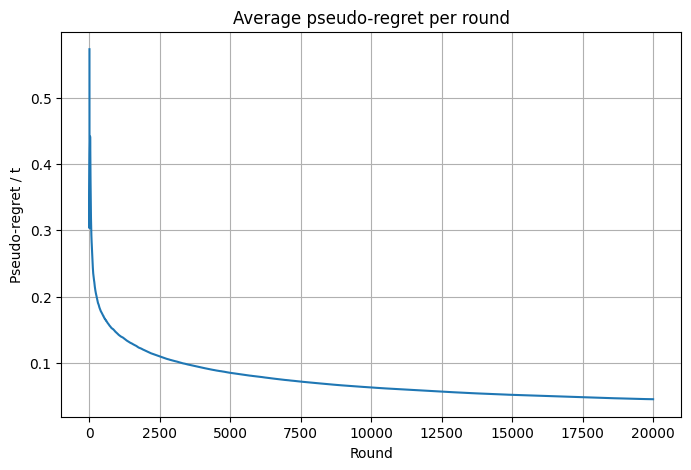

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, avg_pseudo_regret / x)
plt.xlabel("Round")
plt.ylabel("Pseudo-regret / t")
plt.title("Average pseudo-regret per round")
plt.grid(True)
plt.show()


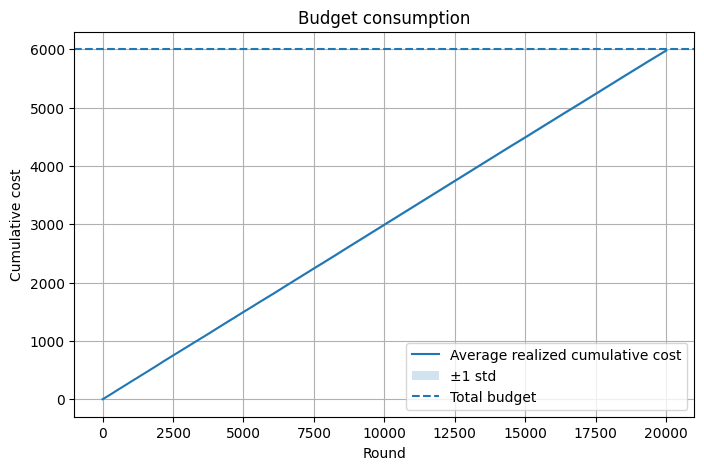

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, avg_cost, label="Average realized cumulative cost")
plt.fill_between(x, avg_cost - std_cost, avg_cost + std_cost, alpha=0.2, label="±1 std")
plt.axhline(total_budget, linestyle="--", label="Total budget")
plt.xlabel("Round")
plt.ylabel("Cumulative cost")
plt.title("Budget consumption")
plt.grid(True)
plt.legend()
plt.show()


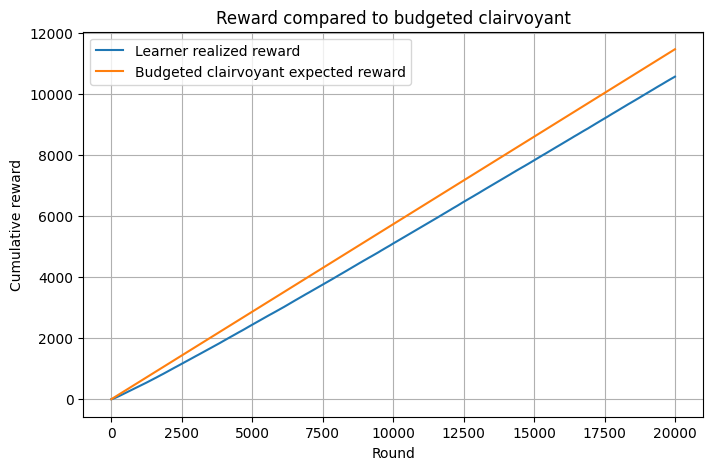

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, reward_trials.mean(axis=0), label="Learner realized reward")
plt.plot(x, x * clairvoyant_expected_reward, label="Budgeted clairvoyant expected reward")
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.title("Reward compared to budgeted clairvoyant")
plt.grid(True)
plt.legend()
plt.show()
